In [10]:
import torch
import torch.linalg as LA


# pos_features_path = "/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/features/save_hidden_states_for_l2s_llava_pope_train_features_pos_answers_14_all_all_train_-1.pth"
# neg_features_path = "/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/features/save_hidden_states_for_l2s_llava_pope_train_features_neg_answers_14_all_all_train_-1.pth"

pos_features_path = "/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/features/save_hidden_states_for_l2s_qwen2vlinstruct_pope_train_features_pos_answers_17_all_all_train_-1.pth"
neg_features_path = "/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/features/save_hidden_states_for_l2s_qwen2vlinstruct_pope_train_features_neg_answers_17_all_all_train_-1.pth"
pos_features = torch.load(pos_features_path)
neg_features = torch.load(neg_features_path)

print(pos_features.keys())
print(neg_features.keys())

dict_keys(['response', 'image', 'model_predictions', 'hidden_states'])
dict_keys(['response', 'image', 'model_predictions', 'hidden_states'])


In [11]:
pos_features["hidden_states"]

[{'model.layers.17': {'inputs': {'last_raw_input': tensor([[ 1.4941, -1.1201,  0.2483,  ...,  0.4229, -0.0668, -0.5132]],
           dtype=torch.float16)},
   'outputs': {'average': tensor([[ 0.3582, -0.3369,  0.0354,  ...,  0.5073, -0.4399, -0.0443]],
           dtype=torch.float16),
    'last_input': tensor([[ 0.1909, -0.7944,  0.1000,  ...,  1.2812, -0.0837, -0.6948]],
           dtype=torch.float16)}}},
 {'model.layers.17': {'inputs': {'last_raw_input': tensor([[-0.1021, -0.7979,  0.2308,  ...,  0.2854,  0.3311, -0.5527]],
           dtype=torch.float16)},
   'outputs': {'average': tensor([[ 0.2122, -0.4211,  0.1167,  ...,  0.0910, -0.5132, -0.0442]],
           dtype=torch.float16),
    'last_input': tensor([[ 0.1216, -1.0410,  0.3955,  ...,  1.2207, -0.2822, -0.6230]],
           dtype=torch.float16)}}},
 {'model.layers.17': {'inputs': {'last_raw_input': tensor([[ 0.1113, -0.8848,  0.0024,  ...,  0.1355,  0.5537, -0.8047]],
           dtype=torch.float16)},
   'outputs': {'averag

In [12]:
# pos_features["response"][0]
# pos_features["hidden_states"][0]["language_model.model.layers.17"]["outputs"].keys()


In [13]:
non_hal_features = []
hal_features = []

for i in range(len(pos_features["hidden_states"])):
    non_hal_features.append(pos_features["hidden_states"][i]['model.layers.17']["outputs"]["average"])
    hal_features.append(neg_features["hidden_states"][i]['model.layers.17']["outputs"]["average"])
    


hal_features = torch.cat(hal_features, dim=0)
non_hal_features = torch.cat(non_hal_features, dim=0)


print(hal_features.shape)
print(non_hal_features.shape)

torch.Size([6300, 3584])
torch.Size([6300, 3584])


In [14]:
from utils_milad import *

X = torch.cat([hal_features, non_hal_features], dim=0)
y = torch.cat([torch.ones(hal_features.shape[0]), torch.zeros(non_hal_features.shape[0])], dim=0)
# 1: hallucinated, 0: non-hallucinated


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True,stratify=y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


X_train_mean = X_train.mean(dim=0)
X_train = X_train - X_train_mean
X_test = X_test - X_train_mean


torch.Size([10080, 3584])
torch.Size([2520, 3584])
torch.Size([10080])
torch.Size([2520])


/research/hal-afsharim/learn-to-steer/src/examples/milad/utils_milad.py:96: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, device=DEVICE)


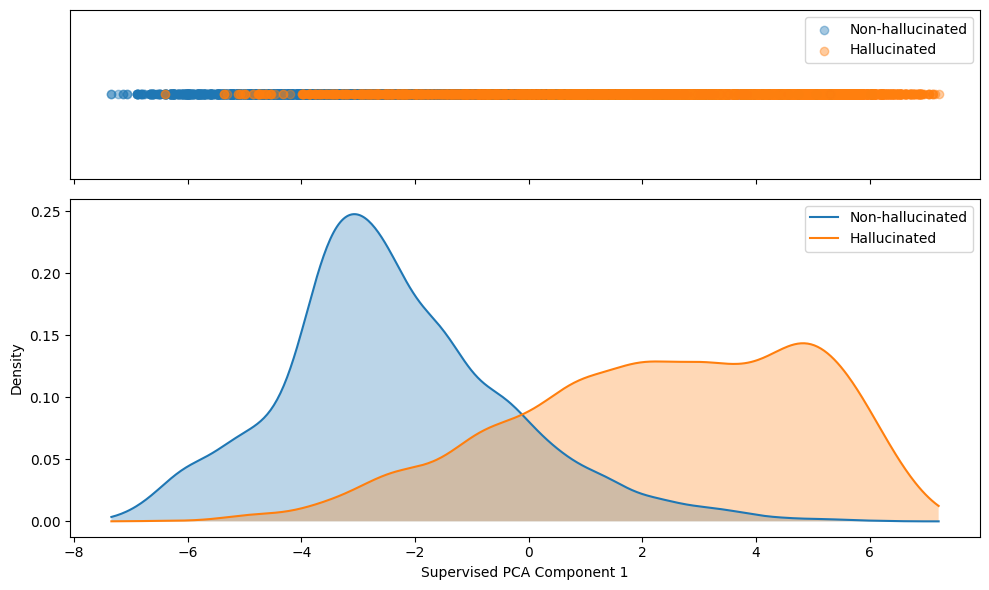

In [15]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

L = label_kernel(y_train)


Z_tr, Z_te, U = supervised_pca(X_train.T, L, X_test=X_test.T, n_components=1)



Z_tr_np = Z_tr.squeeze().cpu().numpy()
y_np    = y_train.cpu().numpy()

z0 = Z_tr_np[y_np == 0]
z1 = Z_tr_np[y_np == 1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                gridspec_kw={"height_ratios": [1, 2]})

# ── Top: scatter ──────────────────────────────────────────────────────────────
ax1.scatter(z0, np.zeros(len(z0)), alpha=0.4, label="Non-hallucinated")
ax1.scatter(z1, np.zeros(len(z1)), alpha=0.4, label="Hallucinated")
ax1.set_yticks([])
ax1.legend()

# ── Bottom: KDE ───────────────────────────────────────────────────────────────
x_range = np.linspace(Z_tr_np.min(), Z_tr_np.max(), 500)

kde0 = gaussian_kde(z0)
kde1 = gaussian_kde(z1)

ax2.plot(x_range, kde0(x_range), label="Non-hallucinated")
ax2.plot(x_range, kde1(x_range), label="Hallucinated")
ax2.fill_between(x_range, kde0(x_range), alpha=0.3)
ax2.fill_between(x_range, kde1(x_range), alpha=0.3)
ax2.set_xlabel("Supervised PCA Component 1")
ax2.set_ylabel("Density")
ax2.legend()

plt.tight_layout()
plt.show()


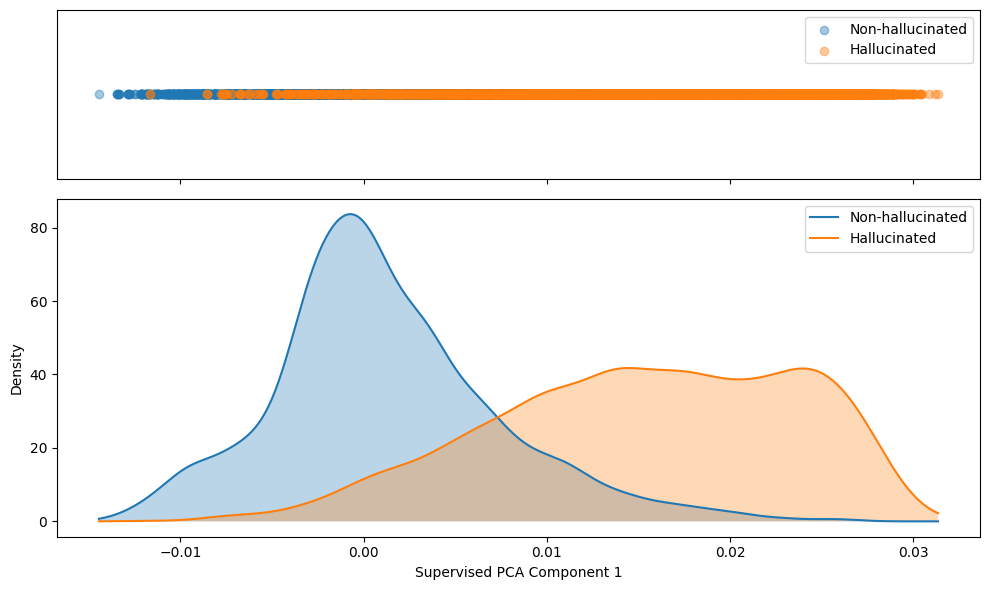

In [16]:


# Usage
project  = make_rff_projector(p=X_train.shape[1], rff_dim=6000, gamma=4.5e-6)

Phi_train = project(X_train).T   # (D, n)
Phi_test  = project(X_test).T    # (D, m)

Z_tr, Z_te, U = supervised_pca(Phi_train, L, X_test=Phi_test, n_components=1)


Z_tr_np = Z_tr.squeeze().cpu().numpy()
y_np    = y_train.cpu().numpy()

z0 = Z_tr_np[y_np == 0]
z1 = Z_tr_np[y_np == 1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                gridspec_kw={"height_ratios": [1, 2]})

# ── Top: scatter ──────────────────────────────────────────────────────────────
ax1.scatter(z0, np.zeros(len(z0)), alpha=0.4, label="Non-hallucinated")
ax1.scatter(z1, np.zeros(len(z1)), alpha=0.4, label="Hallucinated")
ax1.set_yticks([])
ax1.legend()

# ── Bottom: KDE ───────────────────────────────────────────────────────────────
x_range = np.linspace(Z_tr_np.min(), Z_tr_np.max(), 500)

kde0 = gaussian_kde(z0)
kde1 = gaussian_kde(z1)

ax2.plot(x_range, kde0(x_range), label="Non-hallucinated")
ax2.plot(x_range, kde1(x_range), label="Hallucinated")
ax2.fill_between(x_range, kde0(x_range), alpha=0.3)
ax2.fill_between(x_range, kde1(x_range), alpha=0.3)
ax2.set_xlabel("Supervised PCA Component 1")
ax2.set_ylabel("Density")
ax2.legend()

plt.tight_layout()
plt.show()

/research/hal-afsharim/learn-to-steer/src/examples/milad/utils_milad.py:96: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, device=DEVICE)


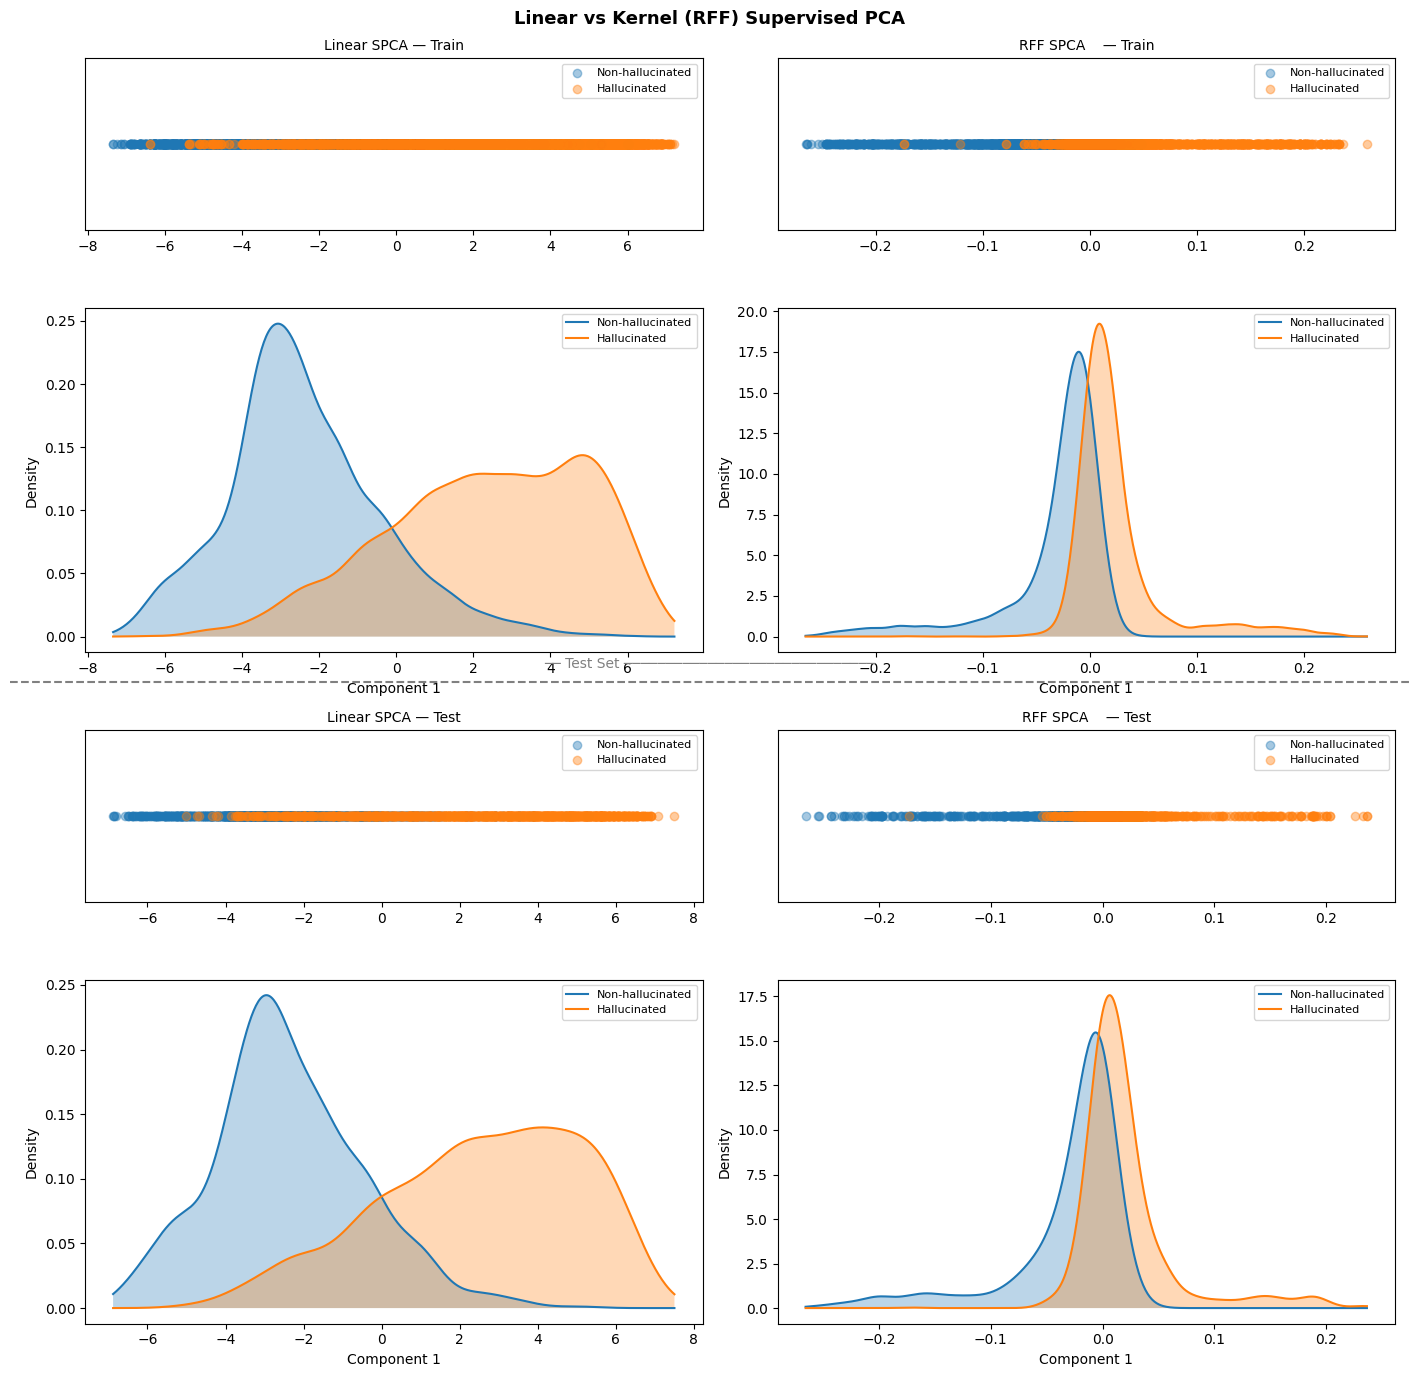

In [32]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

gamma = 4e-2


L      = label_kernel(y_train)
y_tr   = y_train.cpu().numpy()
y_te   = y_test.cpu().numpy()

# ── Run both methods ──────────────────────────────────────────────────────────

Z_tr_lin, Z_te_lin, _ = supervised_pca(X_train.T, L, X_test=X_test.T, n_components=1)

project        = make_rff_projector(p=X_train.shape[1], rff_dim=6000, gamma=gamma)
Phi_train      = project(X_train).T
Phi_test       = project(X_test).T
Z_tr_rff, Z_te_rff, _ = supervised_pca(Phi_train, L, X_test=Phi_test, n_components=1)

# ── Helper ────────────────────────────────────────────────────────────────────

def fill_axes(ax_scatter, ax_kde, Z, y, title):
    z  = Z.squeeze().cpu().numpy()
    z0 = z[y == 0]
    z1 = z[y == 1]

    ax_scatter.scatter(z0, np.zeros(len(z0)), alpha=0.4, label="Non-hallucinated")
    ax_scatter.scatter(z1, np.zeros(len(z1)), alpha=0.4, label="Hallucinated")
    ax_scatter.set_yticks([])
    ax_scatter.set_title(title, fontsize=10)
    ax_scatter.legend(fontsize=8)

    x_range     = np.linspace(z.min(), z.max(), 500)
    kde0, kde1  = gaussian_kde(z0), gaussian_kde(z1)
    ax_kde.plot(x_range, kde0(x_range), label="Non-hallucinated")
    ax_kde.plot(x_range, kde1(x_range), label="Hallucinated")
    ax_kde.fill_between(x_range, kde0(x_range), alpha=0.3)
    ax_kde.fill_between(x_range, kde1(x_range), alpha=0.3)
    ax_kde.set_xlabel("Component 1")
    ax_kde.set_ylabel("Density")
    ax_kde.legend(fontsize=8)

# ── 4×2 grid: rows = [train scatter, train kde, test scatter, test kde] ───────
#              cols = [linear, rff]

fig, axes = plt.subplots(4, 2, figsize=(14, 14),
                         gridspec_kw={"height_ratios": [1, 2, 1, 2]})

fill_axes(axes[0, 0], axes[1, 0], Z_tr_lin, y_tr, "Linear SPCA — Train")
fill_axes(axes[0, 1], axes[1, 1], Z_tr_rff, y_tr, "RFF SPCA    — Train")
fill_axes(axes[2, 0], axes[3, 0], Z_te_lin, y_te, "Linear SPCA — Test")
fill_axes(axes[2, 1], axes[3, 1], Z_te_rff, y_te, "RFF SPCA    — Test")

# link x-axes within each column so scales are comparable
for col in [0, 1]:
    axes[0, col].sharex(axes[1, col])
    axes[2, col].sharex(axes[3, col])

# dividing line between train and test sections
fig.add_artist(plt.Line2D([0, 1], [0.5, 0.5],
               transform=fig.transFigure, color="gray",
               linewidth=1.5, linestyle="--"))

fig.text(0.5, 0.97, "Linear vs Kernel (RFF) Supervised PCA",
         ha="center", fontsize=13, fontweight="bold")
fig.text(0.5, 0.51, "── Test Set ──────────────────────────────",
         ha="center", fontsize=10, color="gray")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [ ]:
get_gamma(X_train[:1000])

In [16]:
# A quick sanity check — print the average pairwise distance in your data
dists = torch.cdist(X_train[:1000], X_train[:1000])
print("mean pairwise dist:", dists.mean().item())
print("suggested gamma:   ", (1 / dists.mean().item() ** 2))

mean pairwise dist: 12.4140625
suggested gamma:    0.006488915890833813
